<a href="https://colab.research.google.com/github/MohamedKarimmm/unet_brain_tumor_segmentation/blob/main/Unet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

DATASET_PATH = "/content/drive/MyDrive/breast ultrasound images dataset/Dataset_BUSI_with_GT"
IMG_SIZE = 224

In [ ]:
import os
import cv2
import numpy as np

DATASET_PATH = "/content/drive/MyDrive/breast ultrasound images dataset/Dataset_BUSI_with_GT"
IMG_SIZE = 224

images = []
masks = []

# Assuming the dataset structure is DATASET_PATH / category_folder / image_files (e.g., benign_01.png, benign_01_mask.png)

for category_folder in os.listdir(DATASET_PATH):
    category_path = os.path.join(DATASET_PATH, category_folder)

    # Skip if it's not a directory (e.g., if there are files directly in DATASET_PATH)
    if not os.path.isdir(category_path):
        continue

    # Filtering for benign and malignant categories explicitly as per original intent
    if not ("benign" in category_folder.lower() or "malignant" in category_folder.lower()):
        continue

    for file_name in os.listdir(category_path):
        # Ensure we are processing image files (e.g., .png) and not mask files first
        if not file_name.endswith(".png") or "_mask" in file_name:
            continue

        img_path = os.path.join(category_path, file_name)
        mask_path = os.path.join(category_path, file_name.replace(".png", "_mask.png"))

        # Check if the mask file exists for the current image
        if not os.path.exists(mask_path):
            print(f"Warning: Mask file not found for {file_name}. Skipping.")
            continue

        # image
        img = cv2.imread(img_path)
        if img is None: # Check if image loading was successful
            print(f"Warning: Could not load image from {img_path}. Skipping.")
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # mask (label)
        mask = cv2.imread(mask_path, 0)
        if mask is None: # Check if mask loading was successful
            print(f"Warning: Could not load mask from {mask_path}. Skipping.")
            continue
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
        mask = (mask > 0).astype(np.float32)

        images.append(img)
        masks.append(mask)

X = np.array(images) / 255.0
y = np.array(masks)
y = np.expand_dims(y, axis=-1)

print("Data:", X.shape, y.shape)

Data: (647, 224, 224, 3) (647, 224, 224, 1)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model

def build_unet_pretrained(input_shape=(224,224,3)):

    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    # Freeze encoder
    for layer in base_model.layers:
        layer.trainable = False

    # Skip connections
    s1 = base_model.get_layer("block_1_expand_relu").output   # 112
    s2 = base_model.get_layer("block_3_expand_relu").output   # 56
    s3 = base_model.get_layer("block_6_expand_relu").output   # 28
    s4 = base_model.get_layer("block_13_expand_relu").output  # 14

    b1 = base_model.get_layer("block_16_project").output      # 7

    # Decoder
    d1 = layers.UpSampling2D()(b1)          # 7 → 14
    d1 = layers.concatenate([d1, s4])
    d1 = layers.Conv2D(256, 3, activation='relu', padding='same')(d1)

    d2 = layers.UpSampling2D()(d1)          # 14 → 28
    d2 = layers.concatenate([d2, s3])
    d2 = layers.Conv2D(128, 3, activation='relu', padding='same')(d2)

    d3 = layers.UpSampling2D()(d2)          # 28 → 56
    d3 = layers.concatenate([d3, s2])
    d3 = layers.Conv2D(64, 3, activation='relu', padding='same')(d3)

    d4 = layers.UpSampling2D()(d3)          # 56 → 112
    d4 = layers.concatenate([d4, s1])
    d4 = layers.Conv2D(32, 3, activation='relu', padding='same')(d4)

    # 🔥 الخطوة اللي كانت ناقصة
    d5 = layers.UpSampling2D()(d4)          # 112 → 224
    d5 = layers.Conv2D(16, 3, activation='relu', padding='same')(d5)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(d5)

    return Model(inputs=base_model.input, outputs=outputs)


model = build_unet_pretrained()
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 4,630,337 (17.66 MB)

 Trainable params: 2,788,353 (10.64 MB)

 Non-trainable params: 1,841,984 (7.03 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(patience=3, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(patience=2, factor=0.5, verbose=1)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=8,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 297s 4s/step - accuracy: 0.9087 - dice_coef: 0.3685 - loss: 0.8904 - val_accuracy: 0.9269 - val_dice_coef: 0.5644 - val_loss: 0.6327 - learning_rate: 1.0000e-04
Epoch 2/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 255s 4s/step - accuracy: 0.9308 - dice_coef: 0.5699 - loss: 0.6357 - val_accuracy: 0.9317 - val_dice_coef: 0.5970 - val_loss: 0.5938 - learning_rate: 1.0000e-04
Epoch 3/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 271s 4s/step - accuracy: 0.9338 - dice_coef: 0.5915 - loss: 0.6025 - val_accuracy: 0.9413 - val_dice_coef: 0.6033 - val_loss: 0.5758 - learning_rate: 1.0000e-04
Epoch 4/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 251s 4s/step - accuracy: 0.9445 - dice_coef: 0.6365 - loss: 0.5363 - val_accuracy: 0.9422 - val_dice_coef: 0.6138 - val_loss: 0.5658 - learning_rate: 1.0000e-04
Epoch 5/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 274s 4s/step - accuracy: 0.9469 - dice_coef: 0.6660 - loss: 0.4955 - val_accuracy: 0.9404 - val_dice_coef: 0.6322 - val_loss: 0.5492 - learning_rate: 1.0000e-04
Epoch

In [ ]:
def dice_coef(y_true, y_pred):
    y_true = tf.reshape(y_true, [-1])
    y_pred = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2. * intersection + 1e-7) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + 1e-7)

def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=bce_dice_loss,
    metrics=['accuracy', dice_coef]
)

In [ ]:
pred = model.predict(X_test[:3])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [ ]:
model.evaluate(X_test, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.9446 - dice_coef: 0.6805 - loss: 0.5066


[0.506554901599884, 0.9446382522583008, 0.6804593801498413]

5/5 ━━━━━━━━━━━━━━━━━━━━ 24s 4s/step


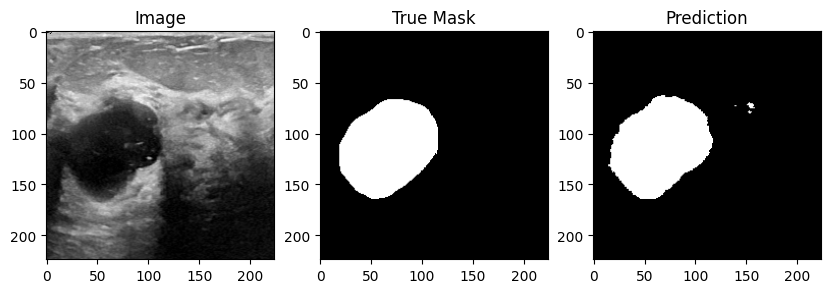

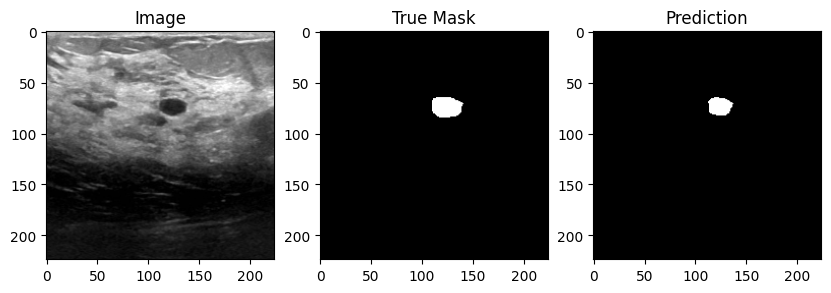

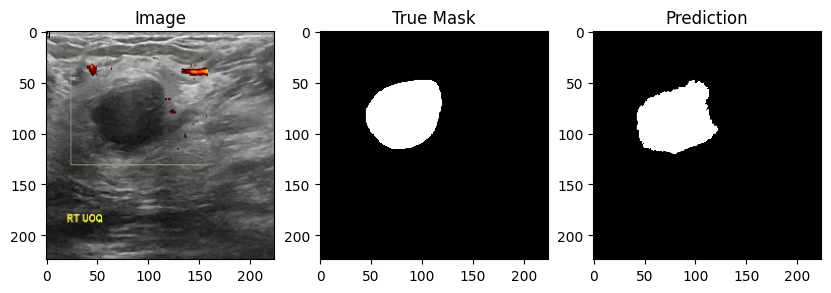

In [ ]:
preds = model.predict(X_test)

for i in range(3):
    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.imshow(X_test[i])
    plt.title("Image")

    plt.subplot(1,3,2)
    plt.imshow(y_test[i].squeeze(), cmap='gray')
    plt.title("True Mask")

    plt.subplot(1,3,3)
    plt.imshow((preds[i] > 0.5).squeeze(), cmap='gray')
    plt.title("Prediction")

    plt.show()

In [ ]:
model.save("unet_model.keras")

In [ ]:
from google.colab import files
files.download("unet_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>